## Binary classification using breast cancer dataset

**Here ANN ARE NOT** good choice for this tabular data. The best choice would be XGBoost (Extreme Gradient Boosting) or LightGBM (Light Gradient Boosting Machine), etc. I am using ANN to solve this problem to show that it can be used in classification problem too

In [2]:
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf

print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)
print(tf.__version__)



1.26.4
2.2.2
1.4.2
2.15.0


In [1]:
import pydot

graphs = pydot.graph_from_dot_data("digraph G {A -> B}")
print("Graphviz + pydot working ✅")

Graphviz + pydot working ✅


In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# from sklearn.datasets import load_breast_cancer
import pandas as pd

In [4]:
df = pd.read_csv("data_breast_cancer.csv")
print(df.head(5))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [5]:
# Extract X (Features) and y (Target) from the DataFrame
X = df.drop(columns=["target"])  # All columns except 'target'
y = df["target"]  # Target variable

In [5]:
print(X.head(5))
print("*************")
print(y.head(5))

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [5]:
#display the shape. rows, with 30 features 
print(f"X shape: {X.shape}")  
print(f"y shape: {y.shape}")  

X shape: (569, 30)
y shape: (569,)


In [6]:
# Split dataset into Training and Testing sets (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
print(f"X train shape: {X_train.shape}")
print(f"X test shape : {X_test.shape}")

X train shape: (455, 30)
X test shape : (114, 30)


In [41]:
print(X_train.head(5)) # lets print 1st 5 records from X_train

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
68         9.029         17.33           58.79      250.5          0.10660   
181       21.090         26.57          142.70     1311.0          0.11410   
63         9.173         13.86           59.20      260.9          0.07721   
248       10.650         25.22           68.01      347.0          0.09657   
60        10.170         14.88           64.55      311.9          0.11340   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
68            0.14130         0.31300              0.04375         0.2111   
181           0.28320         0.24870              0.14960         0.2395   
63            0.08751         0.05988              0.02180         0.2341   
248           0.07234         0.02379              0.01615         0.1897   
60            0.08061         0.01084              0.01290         0.2743   

     mean fractal dimension  ...  worst radius  worst texture  \
68 

In [7]:
# Normalize the features for better performance and for faster convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
print(X_train_scaled[:5]) # lets print 1st few records from X_train

[[-1.44075296 -0.43531947 -1.36208497 -1.1391179   0.78057331  0.71892128
   2.82313451 -0.11914956  1.09266219  2.45817261 -0.26380039 -0.01605246
  -0.47041357 -0.47476088  0.83836493  3.25102691  8.43893667  3.39198733
   2.62116574  2.06120787 -1.23286131 -0.47630949 -1.24792009 -0.97396758
   0.72289445  1.18673232  4.67282796  0.9320124   2.09724217  1.88645014]
 [ 1.97409619  1.73302577  2.09167167  1.85197292  1.319843    3.42627493
   2.01311199  2.66503199  2.1270036   1.55839569  0.80531919 -0.81268678
   0.75195659  0.87716951 -0.89605315  1.18122247  0.18362761  0.60059598
  -0.31771686  0.52963649  2.17331385  1.3112795   2.08161691  2.1374055
   0.76192793  3.26560084  1.92862053  2.6989469   1.89116053  2.49783848]
 [-1.39998202 -1.24962228 -1.34520926 -1.10978518 -1.33264483 -0.30735463
  -0.36555756 -0.69650228  1.93033305  0.95437877  0.02752055  1.96305996
  -0.12095781 -0.35077918  0.57276579  0.7394992   0.32065553  0.58946222
   2.61504052  0.71892779 -1.29528358

In [9]:
# Define the Model

model = models.Sequential([
    # Hidden Layer 1 (8 neurons)
    layers.Dense(units=8, input_shape=(30,), activation='relu'),

    # Hidden Layer 2 (4 neurons)
    layers.Dense(units=4, activation='relu'),  

    # Output Layer (1 neuron for binary classification)
    layers.Dense(units=1, activation='sigmoid')  
])

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 248       
                                                                 
 dense_1 (Dense)             (None, 4)                 36        
                                                                 
 dense_2 (Dense)             (None, 1)                 5         
                                                                 
Total params: 289 (1.13 KB)
Trainable params: 289 (1.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


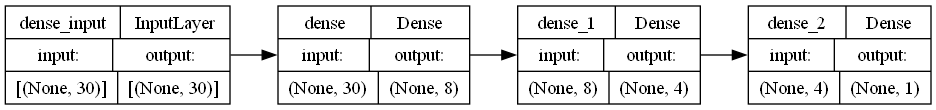

In [10]:
# Lets visualize
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='model.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='LR'   # TB Top to Bottom (vertical)
)


In [11]:
# Compile the Model
model.compile(optimizer='adam', 
              loss='binary_crossentropy',
              metrics=['accuracy']
)

# Train the Model
history = model.fit(X_train_scaled, y_train, 
                    epochs=5, 
                    batch_size=10, 
                    validation_data=(X_test, y_test), 
                    verbose=1
)

# Evaluate the Model
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"\nTest Accuracy: {accuracy:.4f}")


Epoch 1/5


46/46 [==============================] - 2s 9ms/step - loss: 0.6488 - accuracy: 0.5516 - val_loss: 65.0329 - val_accuracy: 0.3772
Epoch 2/5
46/46 [==============================] - 0s 3ms/step - loss: 0.5529 - accuracy: 0.8505 - val_loss: 93.2960 - val_accuracy: 0.3772
Epoch 3/5
46/46 [==============================] - 0s 3ms/step - loss: 0.5018 - accuracy: 0.9209 - val_loss: 151.3463 - val_accuracy: 0.3772
Epoch 4/5
46/46 [==============================] - 0s 3ms/step - loss: 0.4685 - accuracy: 0.9451 - val_loss: 200.7394 - val_accuracy: 0.3772
Epoch 5/5
4/4 [==============================] - 0s 3ms/step - loss: 0.4358 - accuracy: 0.9561

Test Accuracy: 0.9561


In [16]:
# 1) Get a sample + predict values from test dataset

print(list(X_test.iloc[3])) # get a sample
print(y_test.iloc[3])  # and its predicted value

[12.4, 17.68, 81.47, 467.8, 0.1054, 0.1316, 0.07741, 0.02799, 0.1811, 0.07102, 0.1767, 1.46, 2.204, 15.43, 0.01, 0.03295, 0.04861, 0.01167, 0.02187, 0.006005, 12.88, 22.91, 89.61, 515.8, 0.145, 0.2629, 0.2403, 0.0737, 0.2556, 0.09359]
1


In [21]:
X_sample = X_test.iloc[[3]]
X_sample_scaled = scaler.transform(X_sample) 
y_pred = model.predict(X_sample_scaled)
print("prediction probability:", y_pred)

# If binary classification → convert to 0/1
y_pred_class = (y_pred > 0.5).astype(int)

print("\nSample Prediction (probability):", y_pred)
print("Sample Prediction (class):", y_pred_class)

1/1 [==============================] - 0s 92ms/step

Sample Prediction (probability): [[0.5515835]]
Sample Prediction (class): [[1]]


In [26]:
# Make Predictions on test dataset

predicted_prob = model.predict(X_test_scaled) 
y_pred = ( predicted_prob > 0.5).astype(int)  # Convert probabilities to 0 or 1

# print("predicted_prob:", np.round(predicted_prob[:10], 2).tolist())
print("\nSample Predictions:", list(y_pred[:10].flatten()))
print("\nSample Actual     :", list(y_test[:10]))

4/4 [==============================] - 0s 2ms/step

Sample Predictions: [1, 0, 0, 1, 1, 0, 0, 0, 0, 1]

Sample Actual     : [1, 0, 0, 1, 1, 0, 0, 0, 1, 1]


[[42  1]
 [ 4 67]]


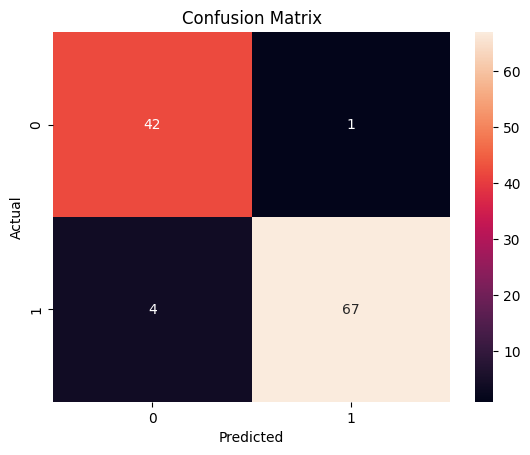

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()